# 03) Baseline Models and Feature Selection

In [1]:
import json

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import warnings

from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train = pd.read_csv("data/train.csv", parse_dates=["date"])
with open("data/columns.json") as f:
    columns = json.load(f)

TARGET_COL = columns["target_cols"][0]
FEATURE_COLS = columns["feature_cols"]

print(f"train: {train.shape[0]} rows, {len(FEATURE_COLS)} features, target = {TARGET_COL!r}")

train: 8443 rows, 30 features, target = 'target_bps_vs_mid'


## Expanding-window cross-validation split

A single fixed fit/eval split gives one point estimate of eval MSE, entirely dependent on which
handful of days happened to land in eval -- not something to pick a penalty on with confidence.
Expanding-window CV rolls the eval block forward across multiple folds: each fold trains on every
day strictly before its eval block (never after -- no lookahead) and the training window grows as
the boundary moves forward. `data/test.csv` is still untouched; all folds live inside
`data/train.csv`.

Walk-forward, one day at a time: fold 0 trains on the first `MIN_TRAIN_DAYS` days and evals on the
next single day; each later fold folds that eval day into training and evals on the day after it.
`MIN_TRAIN_DAYS` is the warm-up -- how much history a fold needs before it's trusted to fit at all.

In [2]:
unique_dates = np.sort(train["date"].unique())
MIN_TRAIN_DAYS = 7
DELTA_DAYS = 1

folds = []
for fold_idx, eval_start in enumerate(range(MIN_TRAIN_DAYS, len(unique_dates), DELTA_DAYS)):
    fit_dates = unique_dates[:eval_start]
    eval_dates = unique_dates[eval_start:eval_start + DELTA_DAYS]
    assert fit_dates.max() < eval_dates.min(), "eval dates must all fall after fit dates"

    fit_mask = train["date"].isin(fit_dates)
    eval_mask = train["date"].isin(eval_dates)
    folds.append((fit_mask, eval_mask))

    print(f"fold {fold_idx}: fit {fit_mask.sum():>4} rows ({len(fit_dates)} days, "
          f"{pd.Timestamp(fit_dates.min()).date()} to {pd.Timestamp(fit_dates.max()).date()}) | "
          f"eval {eval_mask.sum():>4} rows ({len(eval_dates)} days, "
          f"{pd.Timestamp(eval_dates.min()).date()} to {pd.Timestamp(eval_dates.max()).date()})")

fold 0: fit 3476 rows (7 days, 2025-03-03 to 2025-03-11) | eval  496 rows (1 days, 2025-03-12 to 2025-03-12)
fold 1: fit 3972 rows (8 days, 2025-03-03 to 2025-03-12) | eval  497 rows (1 days, 2025-03-13 to 2025-03-13)
fold 2: fit 4469 rows (9 days, 2025-03-03 to 2025-03-13) | eval  497 rows (1 days, 2025-03-14 to 2025-03-14)
fold 3: fit 4966 rows (10 days, 2025-03-03 to 2025-03-14) | eval  497 rows (1 days, 2025-03-17 to 2025-03-17)
fold 4: fit 5463 rows (11 days, 2025-03-03 to 2025-03-17) | eval  496 rows (1 days, 2025-03-18 to 2025-03-18)
fold 5: fit 5959 rows (12 days, 2025-03-03 to 2025-03-18) | eval  497 rows (1 days, 2025-03-19 to 2025-03-19)
fold 6: fit 6456 rows (13 days, 2025-03-03 to 2025-03-19) | eval  496 rows (1 days, 2025-03-20 to 2025-03-20)
fold 7: fit 6952 rows (14 days, 2025-03-03 to 2025-03-20) | eval  497 rows (1 days, 2025-03-21 to 2025-03-21)
fold 8: fit 7449 rows (15 days, 2025-03-03 to 2025-03-21) | eval  497 rows (1 days, 2025-03-24 to 2025-03-24)
fold 9: fit 7

## Elastic net, 6x6 grid over alpha and l1_ratio

Ridge -> elastic net: `alpha` (overall penalty strength) and `l1_ratio` (mix between L1/Lasso,
`l1_ratio=1`, and L2/Ridge, `l1_ratio=0`) are tuned jointly on a 6x6 grid, 36 combinations, each
scored the same way as before -- fit on each fold's `fit` side, MSE/R^2/IC on both sides, averaged
across the 10 expanding-window folds. Same pipeline otherwise: median-impute -> standardize ->
model, both fit on `fit` only.

`data/train.csv`/`data/columns.json` now reflect the pruned, 30-feature set from `02)` (raw
non-stationary price levels moved to `IDENTIFIER_COLS`), so this also re-runs the whole sweep
against the corrected features, not just swapping the model.

In [3]:
warnings.filterwarnings("ignore", category=UserWarning)  # l1_ratio=0 -> "use Ridge instead"

alphas = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0]
l1_ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
results = []

for alpha in alphas:
    for l1_ratio in l1_ratios:
        fit_mses, eval_mses = [], []
        fit_r2s, eval_r2s = [], []
        fit_ics, eval_ics = [], []
        for fit_mask, eval_mask in folds:
            X_fit, y_fit = train.loc[fit_mask, FEATURE_COLS], train.loc[fit_mask, TARGET_COL]
            X_eval, y_eval = train.loc[eval_mask, FEATURE_COLS], train.loc[eval_mask, TARGET_COL]

            model = Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
                ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10_000)),
            ])
            model.fit(X_fit, y_fit)

            pred_fit = model.predict(X_fit)
            pred_eval = model.predict(X_eval)

            fit_mses.append(mean_squared_error(y_fit, pred_fit))
            eval_mses.append(mean_squared_error(y_eval, pred_eval))
            fit_r2s.append(r2_score(y_fit, pred_fit))
            eval_r2s.append(r2_score(y_eval, pred_eval))
            fit_ics.append(spearmanr(y_fit, pred_fit).statistic)
            eval_ics.append(spearmanr(y_eval, pred_eval).statistic)

        results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "fit_mse": np.mean(fit_mses),
            "eval_mse_mean": np.mean(eval_mses),
            "eval_mse_std": np.std(eval_mses),
            "fit_r2": np.mean(fit_r2s),
            "eval_r2": np.mean(eval_r2s),
            "fit_ic": np.mean(fit_ics),
            "eval_ic": np.mean(eval_ics),
        })

results_df = pd.DataFrame(results).sort_values("eval_mse_mean").reset_index(drop=True)
print(results_df.to_string(index=False))

print()
print("eval_mse_mean grid (rows=alpha, cols=l1_ratio):")
pivot = pd.DataFrame(results).pivot(index="alpha", columns="l1_ratio", values="eval_mse_mean")
print(pivot.to_string())

 alpha  l1_ratio   fit_mse  eval_mse_mean  eval_mse_std   fit_r2  eval_r2   fit_ic  eval_ic
 0.100       1.0 13.357665      10.112786      2.608471 0.817995 0.816355 0.824449 0.823747
 0.030       1.0 13.239759      10.193138      2.636631 0.819599 0.814830 0.824845 0.823606
 0.300       1.0 13.626527      10.239783      2.603344 0.814339 0.815678 0.822734 0.821558
 0.030       0.8 13.231727      10.323064      2.661092 0.819707 0.813150 0.824861 0.823452
 0.100       0.8 13.367127      10.380026      2.785595 0.817867 0.814150 0.824949 0.824264
 0.030       0.6 13.233780      10.482041      2.676303 0.819678 0.810731 0.824854 0.823299
 0.010       1.0 13.197808      10.608287      2.469327 0.820161 0.804350 0.824217 0.822295
 0.030       0.4 13.243784      10.657101      2.707535 0.819542 0.808044 0.824761 0.822895
 0.010       0.8 13.195740      10.674069      2.484912 0.820189 0.803251 0.824181 0.822145
 0.100       0.6 13.432972      10.720096      3.070520 0.816978 0.810696 0.8251

## Coefficients, with bootstrap t-stats

Elastic net coefficients are biased by construction (that's what the penalty does), so there's no
closed-form OLS-style standard error to divide by -- a naive t-stat off the fitted coefficient alone
would be fiction. Instead: refit the CV-selected `(alpha, l1_ratio)` on 200 block-bootstrap resamples
of `train`, resampling *trading days* with replacement (not individual rows) so a resample never
mixes rows across days in a way the actual data never would -- same reasoning as the day-respecting
CV folds above. `t_stat = mean(beta) / std(beta)` across the 200 refits.

Two things this surfaces that a single point estimate wouldn't: `pct_nonzero` (how often lasso's L1
term keeps a feature at all across resamples -- lasso selection is known to be unstable, so a feature
kept 40% of the time is a different claim than one kept 100% of the time), and coefficients that are
technically nonzero but statistically indistinguishable from 0 once resampling variance is accounted
for (`|t_stat| < 2`).

In [4]:
import matplotlib.pyplot as plt

N_BOOT = 200
rng = np.random.default_rng(0)

best_row = results_df.loc[results_df["eval_mse_mean"].idxmin()]
best_alpha, best_l1_ratio = best_row["alpha"], best_row["l1_ratio"]
print(f"refitting at CV-selected alpha={best_alpha}, l1_ratio={best_l1_ratio} "
      f"on {N_BOOT} day-block bootstrap resamples of the full train set")

unique_train_days = train["date"].unique()
day_to_idx = {d: train.index[train["date"] == d].to_numpy() for d in unique_train_days}

boot_coefs = np.empty((N_BOOT, len(FEATURE_COLS)))
for b in range(N_BOOT):
    boot_days = rng.choice(unique_train_days, size=len(unique_train_days), replace=True)
    idx = np.concatenate([day_to_idx[d] for d in boot_days])
    X_boot, y_boot = train.loc[idx, FEATURE_COLS], train.loc[idx, TARGET_COL]

    model = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("enet", ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10_000)),
    ])
    model.fit(X_boot, y_boot)
    boot_coefs[b] = model.named_steps["enet"].coef_

coef_mean = boot_coefs.mean(axis=0)
coef_se = boot_coefs.std(axis=0, ddof=1)
t_stat = np.divide(coef_mean, coef_se, out=np.full_like(coef_mean, np.nan), where=coef_se > 0)
pct_nonzero = (boot_coefs != 0).mean(axis=0)

coef_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    "beta": coef_mean,
    "se": coef_se,
    "t_stat": t_stat,
    "pct_nonzero": pct_nonzero,
}).sort_values("t_stat", key=lambda s: s.abs(), ascending=False, na_position="last").reset_index(drop=True)

print(coef_table.to_string(index=False))

refitting at CV-selected alpha=0.1, l1_ratio=1.0 on 200 day-block bootstrap resamples of the full train set

                       feature      beta       se    t_stat  pct_nonzero
         near_price_vs_mid_bps  7.108024 0.774724  9.174915        1.000
                       urgency  0.479134 0.126892  3.775925        0.995
          ref_price_vs_mid_bps  0.671230 0.375561  1.787273        0.990
         ref_price_ret_30s_bps -0.163058 0.132855 -1.227340        0.830
         ref_price_ret_10s_bps -0.110366 0.103680 -1.064489        0.755
             intraday_move_bps -0.051894 0.053977 -0.961419        0.735
signed_imbalance_ratio_chg_10s  0.052436 0.056984  0.920185        0.675
                       bid_qty  0.018043 0.019793  0.911587        0.690
signed_imbalance_ratio_chg_30s  0.023744 0.040249  0.589913        0.425
signed_imbalance_ratio_chg_60s  0.015734 0.028960  0.543286        0.370
       imbalance_ratio_chg_10s  0.011737 0.021678  0.541410        0.360
                           adv  0.009305 0.019799  0.469956        0.290
                        spread -0.007232 0.019055 -

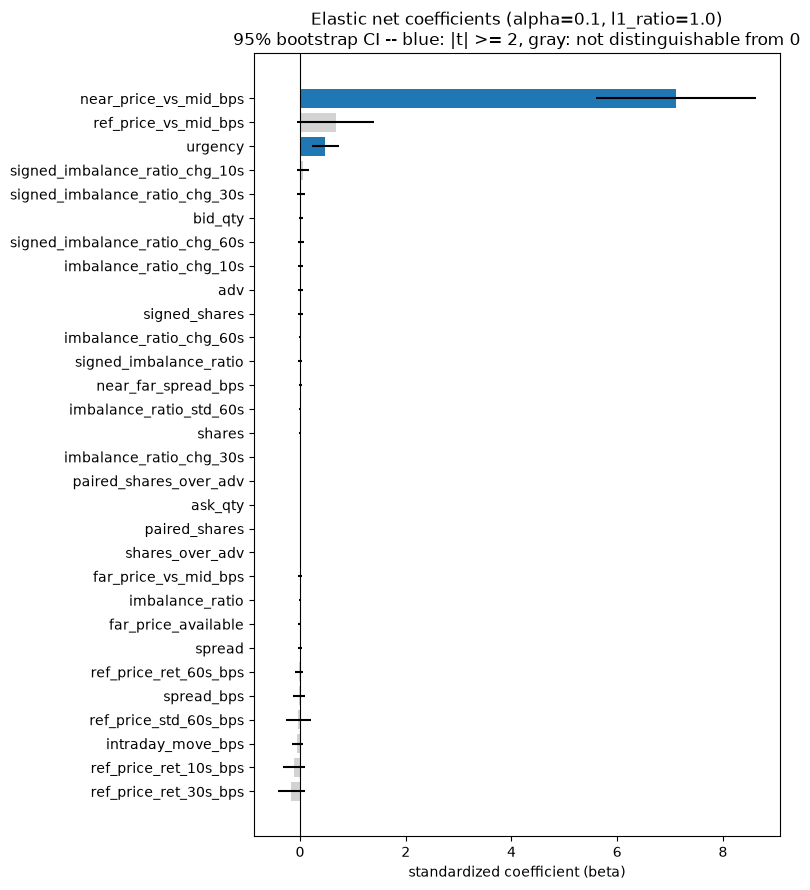

In [5]:
plot_df = coef_table.sort_values("beta")
colors = np.where(plot_df["t_stat"].abs() >= 2, "tab:blue", "lightgray")

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(plot_df["feature"], plot_df["beta"], xerr=1.96 * plot_df["se"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient (beta)")
ax.set_title(
    f"Elastic net coefficients (alpha={best_alpha}, l1_ratio={best_l1_ratio})\n"
    "95% bootstrap CI -- blue: |t| >= 2, gray: not distinguishable from 0"
)
fig.tight_layout()
plt.show()

So essentially most of these features don't mean anything, linearly at least. We will see now whether non-linearly they might mean something

## Non-linear model: LightGBM + SHAP + SAGE

Everything above is a linear model -- lasso can pick out which features matter, but it can only ever
find a *linear* relationship between a feature and the target. A small gradient-boosted tree model
checks whether the non-linear/interaction structure lasso is structurally blind to actually matters
here, and SHAP/SAGE ask the same "which features carry signal" question lasso's coefficients
answered, but for a non-linear model.

`LGBMRegressor`, deliberately kept small (`num_leaves=7`, `n_estimators=150`, `learning_rate=0.05`,
`min_child_samples=50` -- shallow trees, heavily regularized against overfitting on 8,443 rows) --
fed the raw `FEATURE_COLS` directly, no impute/scale pipeline needed: LightGBM splits on missing
values natively (handles the `near_far_spread_bps`/`far_price_vs_mid_bps` nulls without an imputer)
and tree splits are invariant to monotonic rescaling, so `StandardScaler` buys nothing here.

First check: does this model actually predict any better than lasso, using the exact same
expanding-window folds and metrics as every model above? If not, the non-linearity isn't earning
its complexity, and SHAP/SAGE below are explaining a model that isn't worth the extra machinery.

In [6]:
import lightgbm as lgb

LGB_PARAMS = dict(num_leaves=7, n_estimators=150, learning_rate=0.05, min_child_samples=50,
                   verbosity=-1, random_state=0)

fit_mses, eval_mses = [], []
fit_r2s, eval_r2s = [], []
fit_ics, eval_ics = [], []
for fit_mask, eval_mask in folds:
    X_fit, y_fit = train.loc[fit_mask, FEATURE_COLS], train.loc[fit_mask, TARGET_COL]
    X_eval, y_eval = train.loc[eval_mask, FEATURE_COLS], train.loc[eval_mask, TARGET_COL]

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(X_fit.to_numpy(), y_fit.to_numpy())

    pred_fit = model.predict(X_fit.to_numpy())
    pred_eval = model.predict(X_eval.to_numpy())

    fit_mses.append(mean_squared_error(y_fit, pred_fit))
    eval_mses.append(mean_squared_error(y_eval, pred_eval))
    fit_r2s.append(r2_score(y_fit, pred_fit))
    eval_r2s.append(r2_score(y_eval, pred_eval))
    fit_ics.append(spearmanr(y_fit, pred_fit).statistic)
    eval_ics.append(spearmanr(y_eval, pred_eval).statistic)

lgb_cv_row = pd.DataFrame([{
    "model": "lightgbm (small)",
    "fit_mse": np.mean(fit_mses),
    "eval_mse_mean": np.mean(eval_mses),
    "eval_mse_std": np.std(eval_mses),
    "fit_r2": np.mean(fit_r2s),
    "eval_r2": np.mean(eval_r2s),
    "fit_ic": np.mean(fit_ics),
    "eval_ic": np.mean(eval_ics),
}, {
    "model": "lasso (alpha=0.1, l1_ratio=1.0)",
    "fit_mse": best_row["fit_mse"],
    "eval_mse_mean": best_row["eval_mse_mean"],
    "eval_mse_std": best_row["eval_mse_std"],
    "fit_r2": best_row["fit_r2"],
    "eval_r2": best_row["eval_r2"],
    "fit_ic": best_row["fit_ic"],
    "eval_ic": best_row["eval_ic"],
}])
print(lgb_cv_row.to_string(index=False))

                          model   fit_mse  eval_mse_mean  eval_mse_std   fit_r2  eval_r2   fit_ic  eval_ic
               lightgbm (small) 19.698813      23.025071     19.018965 0.732483 0.702904 0.834278 0.823307
lasso (alpha=0.1, l1_ratio=1.0) 13.357665      10.112786      2.608471 0.817995 0.816355 0.824449 0.823747


### SHAP

Refit once on the full `train` set (same pattern as the bootstrap coefficient section above), then
`shap.TreeExplainer` -- exact for tree ensembles, no approximation. Beeswarm shows, per feature,
every row's SHAP value (impact on that row's prediction) and its color (that row's feature value) --
direction and magnitude of the non-linear effect at a glance, not just a single importance number.

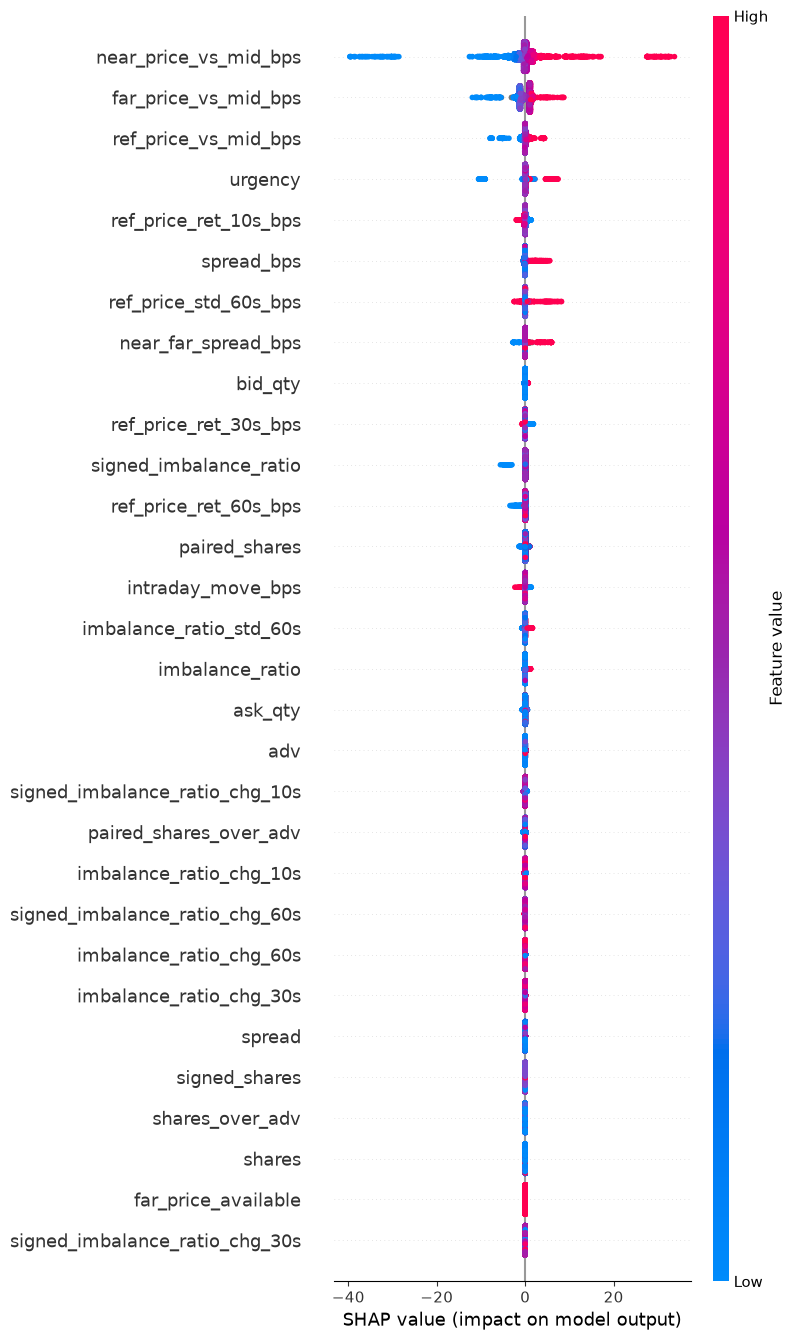

In [7]:
import shap

lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_model.fit(train[FEATURE_COLS].to_numpy(), train[TARGET_COL].to_numpy())

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(train[FEATURE_COLS])

shap.plots.beeswarm(shap_values, max_display=len(FEATURE_COLS), show=False)
plt.tight_layout()
plt.show()

                       feature  mean_abs_shap
         near_price_vs_mid_bps       1.992988
          far_price_vs_mid_bps       1.205420
          ref_price_vs_mid_bps       0.356580
                       urgency       0.193547
         ref_price_ret_10s_bps       0.182213
                    spread_bps       0.124137
         ref_price_std_60s_bps       0.075910
           near_far_spread_bps       0.073196
                       bid_qty       0.051669
         ref_price_ret_30s_bps       0.050771
        signed_imbalance_ratio       0.046699
         ref_price_ret_60s_bps       0.040473
                 paired_shares       0.035461
             intraday_move_bps       0.034885
       imbalance_ratio_std_60s       0.026547
               imbalance_ratio       0.025248
                       ask_qty       0.019680
                           adv       0.011187
signed_imbalance_ratio_chg_10s       0.009285
        paired_shares_over_adv       0.009128
       imbalance_ratio_chg_10s    

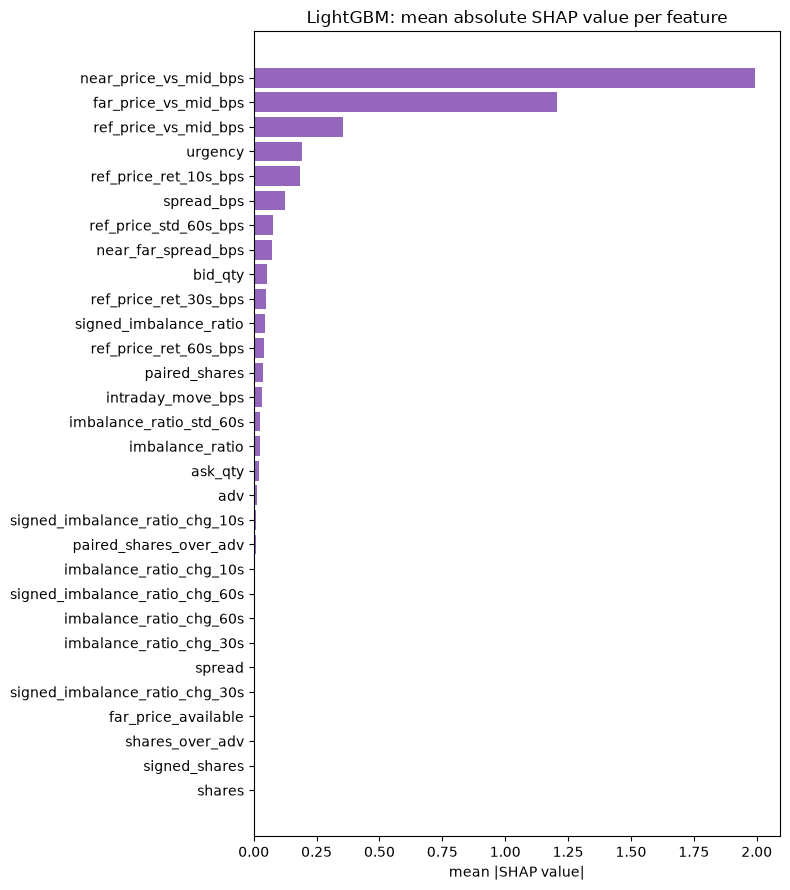

In [8]:
mean_abs_shap = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
print(mean_abs_shap.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 9))
plot_df = mean_abs_shap.sort_values("mean_abs_shap")
ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="tab:purple")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("LightGBM: mean absolute SHAP value per feature")
fig.tight_layout()
plt.show()

### SAGE

SHAP explains individual predictions of *this* model; SAGE (Shapley Additive Global importancE,
Covert et al.) asks a different question -- how much does held-out predictive performance (MSE)
drop if a feature is unknown, averaged over all orderings in which features could be "revealed."
It's model-agnostic and loss-based, not specific to how this particular tree ensemble happens to
split.

`MarginalImputer` needs a background reference sample to draw replacement values from when a
feature is "hidden" (a fixed 512-row sample here -- standard practice, and independent of using the
full `train` set as the data SAGE evaluates importance over, which it does below).
`PermutationEstimator`'s default convergence detection didn't terminate in a reasonable time on this
data (tested and abandoned -- one feature's raw-scale SAGE value is far larger than the others,
which stalls the convergence-ratio criterion); `n_permutations=60` with `detect_convergence=False`
bounds runtime explicitly instead, at some cost to precision on the smallest-magnitude features.

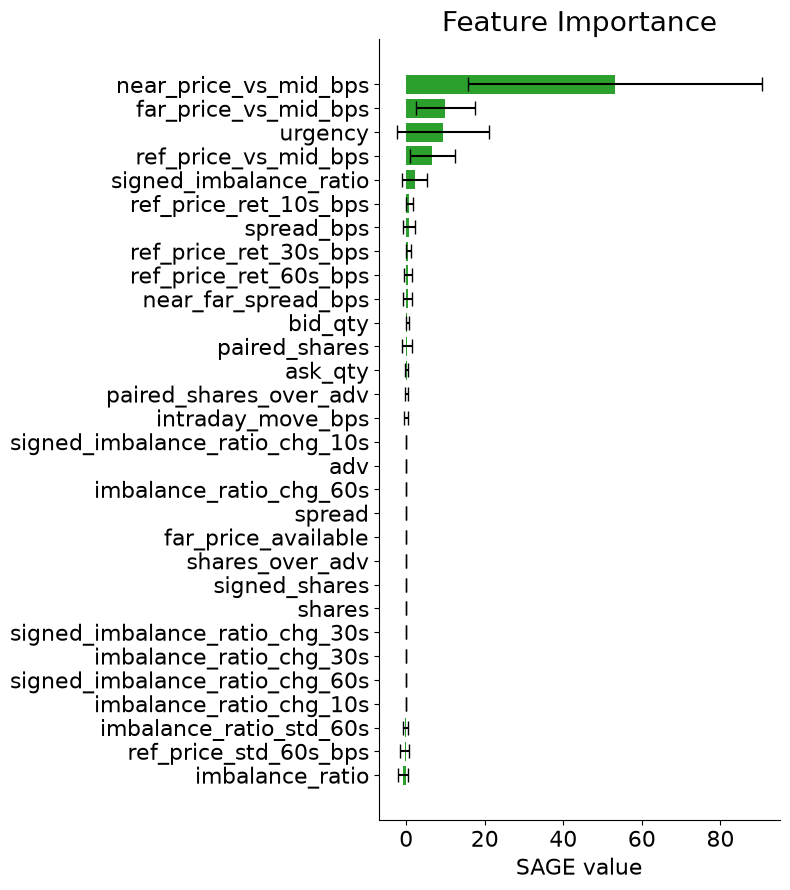

                       feature  sage_value  sage_std
         near_price_vs_mid_bps   53.069174 19.110719
          far_price_vs_mid_bps    9.963253  3.792308
                       urgency    9.310378  5.948623
          ref_price_vs_mid_bps    6.674037  2.939985
        signed_imbalance_ratio    2.221247  1.631256
         ref_price_ret_10s_bps    0.830168  0.469610
                    spread_bps    0.687221  0.756666
         ref_price_ret_30s_bps    0.581759  0.370045
         ref_price_ret_60s_bps    0.484602  0.544451
           near_far_spread_bps    0.363485  0.552685
                       bid_qty    0.286445  0.154432
                 paired_shares    0.195856  0.637235
                       ask_qty    0.139931  0.170196
        paired_shares_over_adv    0.053860  0.170025
             intraday_move_bps    0.046030  0.252374
signed_imbalance_ratio_chg_10s    0.027350  0.024162
                           adv    0.008052  0.020166
       imbalance_ratio_chg_60s    0.003423  0.

In [9]:
import sage

background = train[FEATURE_COLS].sample(n=512, random_state=0)
imputer = sage.MarginalImputer(lgb_model.predict, background.to_numpy())
estimator = sage.PermutationEstimator(imputer, loss="mse", random_state=0)

sage_values = estimator(
    train[FEATURE_COLS].to_numpy(), train[TARGET_COL].to_numpy(),
    n_permutations=60, detect_convergence=False, bar=False,
)

sage.plotting.plot(sage_values, feature_names=FEATURE_COLS, figsize=(8, 9))
plt.show()

sage_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    "sage_value": sage_values.values,
    "sage_std": sage_values.std,
}).sort_values("sage_value", ascending=False).reset_index(drop=True)
print(sage_table.to_string(index=False))

### Do lasso, SHAP, and SAGE agree?

Top 5 features by each method's own ranking -- lasso's `|t_stat|` (bootstrap, linear), SHAP's
`mean |SHAP value|` (per-prediction, this model), SAGE's `sage_value` (loss-based, model-agnostic).

In [10]:
comparison = pd.DataFrame({
    "lasso (|t_stat|)": coef_table.sort_values("t_stat", key=lambda s: s.abs(), ascending=False,
                                                  na_position="last")["feature"].head(5).to_list(),
    "SHAP (mean |value|)": mean_abs_shap["feature"].head(5).to_list(),
    "SAGE (value)": sage_table["feature"].head(5).to_list(),
})
print(comparison.to_string(index=True))

        lasso (|t_stat|)    SHAP (mean |value|)            SAGE (value)
0  near_price_vs_mid_bps  near_price_vs_mid_bps   near_price_vs_mid_bps
1                urgency   far_price_vs_mid_bps    far_price_vs_mid_bps
2   ref_price_vs_mid_bps   ref_price_vs_mid_bps                 urgency
3  ref_price_ret_30s_bps                urgency    ref_price_vs_mid_bps
4  ref_price_ret_10s_bps  ref_price_ret_10s_bps  signed_imbalance_ratio
